# **Introduction**

## 🎯 Objective
* Understand Basic RNN concepts through NLP.
* Understand exactly **why** we need to learn RNN.

## 🧠 Core Concept: Why RNN?
যেকোনো কিছু শেখার আগে তার উদ্দেশ্য (purpose) ক্লিয়ার থাকা দরকার। আমরা আগে সাধারণ নিউরাল নেটওয়ার্ক এবং CNN সম্পর্কে জেনেছি। তাদের সাথে RNN এর মূল পার্থক্য হলো ডেটার ধরনে:

* **ANN (Artificial Neural Network):** এটি মূলত **Tabular বা Non-sequential** ডেটা (যেমন: এক্সেল শিটের ডেটা, যেখানে একটি রো-এর সাথে অন্য রো-এর কোনো সিরিয়াল বা টাইমিংয়ের সম্পর্ক নেই) নিয়ে কাজ করার জন্য ভালো।
* **CNN (Convolutional Neural Network):** এটি মূলত **Image Data** (বা Spatial data) থেকে ফিচার বের করার জন্য কাজ করে।
* **RNN (Recurrent Neural Network):** আমরা এটি ব্যবহার করি **Sequential Data**-এর জন্য। যেমন: টেক্সট (Text), কথা (Speech), বা টাইম-সিরিজ ডেটা। এখানে আগের ডেটার সাথে পরের ডেটার একটি সিকোয়েন্স বা ধারাবাহিক সম্পর্ক থাকে।



## 🗺️ Learning Roadmap
আমরা ধাপে ধাপে নিচের বিষয়গুলো শিখব:

1. **Simple RNN through NLP:** NLP-এর ক্ষেত্রে একটি সাধারণ RNN কীভাবে কাজ করে।
2. **Feed Forward and Backward Propagation of RNN:** RNN-এর ভেতরের ম্যাথ কীভাবে কাজ করে এবং কীভাবে এটি ভুল থেকে শেখে।
3. **Simple RNN Project:** কোড দিয়ে একটি প্র্যাকটিক্যাল ইমপ্লিমেন্টেশন।
4. **LSTM (Long Short-Term Memory):** Simple RNN-এর কিছু সীমাবদ্ধতা (যেমন: Long-term dependency মনে রাখতে না পারা) দূর করার উপায়।
5. **GRU (Gated Recurrent Unit):** LSTM-এর একটি সহজ এবং ফাস্ট ভার্সন।

## 🚀 The Ultimate Goal
আমাদের এই টপিকগুলো শেখার মূল উদ্দেশ্য হলো অ্যাডভান্সড **NLP** এবং **LLM (Large Language Model)** শেখা।

আমরা যদি এখানে Simple RNN-এর Feed Forward এবং Backward Propagation খুব ভালোভাবে বুঝতে পারি, তাহলে ভবিষ্যতে LLM-এর কোর কনসেপ্ট, বিশেষ করে **Encoder and Decoder** আর্কিটেকচার বুঝতে আমাদের অনেক বেশি সুবিধা হবে।


# **What and Why is RNN?**

## 🧠 Introduction
**RNN (Recurrent Neural Network)** হলো এক বিশেষ ধরনের নিউরাল নেটওয়ার্ক আর্কিটেকচার, যা মূলত **Sequential Data** (ধারাবাহিক ডেটা) নিয়ে কাজ করার জন্য ডিজাইন করা হয়েছে।

এর আগে আমরা ANN এবং CNN শিখেছি, চলো আগে দেখি সেগুলোর সাথে RNN-এর মূল পার্থক্য কোথায়।

## 🔍 Why not ANN or CNN?
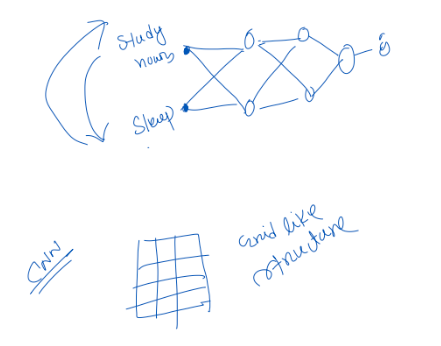

### 1. ANN (Artificial Neural Network)
ANN মূলত **Tabular বা Non-sequential** ডেটা নিয়ে কাজ করে।
* **উদাহরণ (Image 01):** ধরো, আমরা প্রেডিক্ট করতে চাই একজন স্টুডেন্ট পাস করবে নাকি ফেল। আমাদের ফিচার হলো `Study Hours` এবং `Sleep`।
* **লজিক:** আমরা যদি ইনপুটে `Study Hours`-এর জায়গায় `Sleep` এবং `Sleep`-এর জায়গায় `Study Hours` দিই, তাহলে মডেলের পারফরম্যান্সে কোনো সমস্যা হবে না। কারণ, ANN প্রতিটি ইনপুটের জন্য আলাদা ওয়েইট (Weight) ক্যালকুলেট করে, এখানে ডেটার সিরিয়াল বা অর্ডার কোনো ম্যাটার করে না।

### 2. CNN (Convolutional Neural Network)
CNN মূলত **Grid-like Structure** নিয়ে কাজ করে।
* **উদাহরণ (Image 01):** যেকোনো Image বা ছবি হলো পিক্সেলের একটি গ্রিড। CNN এই পিক্সেলগুলোর ভেতর থেকে প্যাটার্ন বা ফিচার বের করে আনতে এক্সপার্ট।

কিন্তু যখন আমাদের ডেটায় **Sequence** বা সময়ের ধারাবাহিকতা ম্যাটার করে, তখন ANN বা CNN ভালো কাজ করতে পারে না। সেখানেই **RNN**-এর প্রয়োজন হয়।

## 📊 What is Sequential Data?
যে ডেটায় একটি ইলিমেন্ট তার আগের বা পরের ইলিমেন্টের ওপর নির্ভরশীল থাকে এবং তাদের সিরিয়াল পরিবর্তন করলে ডেটার অর্থই বদলে যায়, তাকে Sequential Data বলে।

এর কয়েকটি বড় উদাহরণ হলো:

### 1. Textual Data (NLP)
টেক্সট বা ভাষার ক্ষেত্রে শব্দের সিকোয়েন্স খুবই গুরুত্বপূর্ণ।
* **সঠিক সিকোয়েন্স:** "Hi, This is Aktar." (এর একটি সুন্দর অর্থ আছে)
* **ভুল সিকোয়েন্স:** "Aktar, Hi is This." (শব্দ একই, কিন্তু সিকোয়েন্স ভুল হওয়ায় এর কোনো অর্থ নেই)
যেহেতু NLP (Natural Language Processing)-এর মাধ্যমে আমরা কম্পিউটারকে মানুষের ভাষা বোঝানোর চেষ্টা করি, তাই এখানে শব্দের সিকোয়েন্স বোঝাটা মাস্ট। আর এ জন্যই NLP-তে RNN লাগে।

### 2. Time Series Data

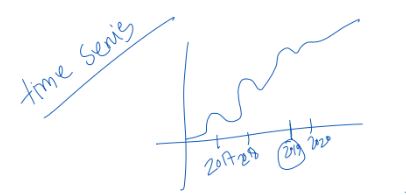

সময়ের সাথে সাথে পরিবর্তনশীল ডেটা।
* **উদাহরণ (Image 02):** কোনো কোম্পানির Stock Market-এর ডেটা। আমরা যদি ২০১৯ সালের গ্রোথ বা স্টক প্রাইস প্রেডিক্ট করতে চাই, তবে অবশ্যই আমাদের ২০১৮ এবং তার আগের ডেটার সিকোয়েন্স জানতে হবে।

### 3. Speech / Audio Data

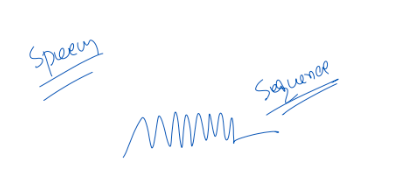

* **উদাহরণ (Image 03):** আমরা যখন কথা বলি, তখন সাউন্ড ওয়েভগুলো (Sound waves) সময়ের সাথে সাথে তৈরি হয়। এটি একটি কন্টিনিউয়াস সিকোয়েন্স। এই স্পিচ রিকগনিশনের জন্যও RNN ব্যবহার করা হয়।

## 🎯 Summary
* **Tabular Data** 👉 ANN
* **Image Data** 👉 CNN
* **Sequential Data (Text, Time Series, Speech)** 👉 RNN

যেহেতু আমাদের চারপাশে প্রচুর Sequential ডেটা আছে, বিশেষ করে ভাষা বা টেক্সট (NLP), তাই মডেলকে এই সিকোয়েন্সের প্যাটার্ন বোঝানোর জন্যই মূলত আমরা RNN ব্যবহার করি।


# **How to Vectorize Textual Data for RNN**

## 🧠 The Problem: Understanding Context & Sentiment
ধরা যাক, আমাদের কাছে দুটি টেক্সট আছে:
1. "I Love AI"
2. "I Hate AI"

আমরা যদি এখানে **Sentiment Analysis** (ইমোশন পজিটিভ নাকি নেগেটিভ তা যাচাই করা) করতে চাই, তাহলে দেখব:
* "I Love AI" ➡️ Positive Sentiment
* "I Hate AI" ➡️ Negative Sentiment (শুধু একটি শব্দ পরিবর্তনের কারণে পুরো ইমোশন বদলে গেল!)

**প্রশ্ন হলো: এই কাজটা কি আমরা সাধারণ ANN (Artificial Neural Network) দিয়ে করতে পারব?**
**উত্তর: না।** কারণ ANN সিকোয়েন্স বা শব্দের ধারাবাহিকতা বোঝে না। ANN-এর কাছে "I Love AI" এবং "AI Love I" একই জিনিস। তাই টেক্সট নিয়ে কাজ করতে হলে আমাদের এমন একটি আর্কিটেকচার লাগবে, যা আগের শব্দের সাথে পরের শব্দের সম্পর্ক বুঝতে পারে।

## 🔢 Converting Text to Numbers (Vectorization)
মেশিন সরাসরি ইংরেজি শব্দ বোঝে না, সে বোঝে শুধু সংখ্যা। তাই টেক্সটকে প্রসেস করার প্রথম ধাপ হলো তাকে নাম্বারে বা ভেক্টরে কনভার্ট করা। একেই **Vectorization** বলে।

চলো ৩টি উদাহরণের মাধ্যমে **One-Hot Encoding** পদ্ধতি দেখি:
* **Sentence 1:** "I love AI"
* **Sentence 2:** "AI loves data"
* **Sentence 3:** "I love data"

### 🔤 Step 1: Build Vocabulary (Unique Words)
প্রথমে পুরো ডেটাসেট থেকে সব ইউনিক শব্দের একটি ডিকশনারি বানাতে হবে:
* I, love, AI, loves, data (মোট ৫টি ইউনিক শব্দ)

### 🔢 Step 2: Assign Index
প্রতিটি শব্দকে একটি ইউনিক ইনডেক্স বা আইডি দেওয়া হলো:
* I ➡️ 0
* love ➡️ 1
* AI ➡️ 2
* loves ➡️ 3
* data ➡️ 4

### 🔥 Step 3: One-Hot Encoding
যেহেতু আমাদের ভোকাবুলারিতে ৫টি শব্দ আছে, তাই প্রতিটি শব্দ ৫ সাইজের একটি ভেক্টর হবে। যেখানে শব্দটির ইনডেক্স থাকবে, সেখানে `1` বসবে, বাকি সব `0`।
* I ➡️ `[1, 0, 0, 0, 0]`
* love ➡️ `[0, 1, 0, 0, 0]`
* AI ➡️ `[0, 0, 1, 0, 0]`
* loves ➡️ `[0, 0, 0, 1, 0]`
* data ➡️ `[0, 0, 0, 0, 1]`

### 📊 Step 4: Encode Each Sentence
এখন আমরা পুরো বাক্যগুলোকে ভেক্টরে রূপান্তর করতে পারি:

**Sentence 1: "I love AI"**
```text
[1, 0, 0, 0, 0] (I)
[0, 1, 0, 0, 0] (love)
[0, 0, 1, 0, 0] (AI)
```

## 🚫 Why ANN Fails for Textual Data
এখন ভেক্টরাইজ তো হলো, কিন্তু ANN কেন কাজ করবে না? এর প্রধান দুটি কারণ আছে:

1. **Fixed Input Size:** ANN-এ ইনপুট লেয়ারের সাইজ ফিক্সড থাকে। ধরো, আমরা "I love AI" (৩টি শব্দ)-এর জন্য একটি মডেল বানালাম। কিন্তু ইউজার যদি ইনপুট দেয় "I love AI so much" (৫টি শব্দ), তখন ANN এরর দেবে। ইনপুট সাইজ ডায়নামিক্যালি চেঞ্জ করার ক্ষমতা ANN-এর নেই।
2. **No Sequence Understanding:** Vectorizer দিয়ে ইনপুট সেম সাইজে আনলেও ANN জানবে না কোন শব্দের আগে কোন শব্দ এসেছে। ANN হলো Feed Forward Neural Network, অর্থাৎ ডেটা শুধু সামনের দিকে যায়। এর Backpropagation শুধুমাত্র ওয়েইট (Weight) আপডেট করে এরর কমানোর জন্য ব্যবহৃত হয়, এটি অতীতের ইনপুট মনে রাখার কোনো মেকানিজম নয়।

## 💡 The RNN Solution (Hidden State)
ঠিক এখানেই **RNN (Recurrent Neural Network)** জাদুর মতো কাজ করে!
* **Memory / Feedback Loop:** RNN-এর স্পেশাল ফিচার হলো, এটি অতীতের ইনফরমেশন মনে রাখতে পারে। কোনো নির্দিষ্ট নিউরনের আউটপুট, পরবর্তী স্টেপে ওই নিউরনেরই ইনপুট হিসেবে প্রবেশ করে (Feedback Loop)।
* **Sequential Processing:** যখন এটি "love" শব্দটা প্রসেস করে, তখন এর কাছে আগের শব্দ "I"-এর ইনফরমেশনটাও সেভ করা থাকে। এই মেকানিজমের কারণেই সেন্টিমেন্ট অ্যানালাইসিস বা যেকোনো NLP টাস্কে RNN এতটা পাওয়ারফুল।

---
**🚀 Pro Tip (অ্যাডভান্সড কনসেপ্ট):**
বাস্তবে আমরা "One-Hot Encoding" খুব বেশি ব্যবহার করি না। কারণ, যদি আমাদের ডিকশনারিতে ১০,০০০ শব্দ থাকে, তবে প্রতিটি শব্দের ভেক্টর সাইজ হবে ১০,০০০ (যাতে ৯,৯৯৯টিই থাকবে জিরো), যা মেমোরির প্রচুর অপচয় করে এবং শব্দগুলোর ভেতরের অর্থগত সম্পর্ক (যেমন: King এবং Man-এর সম্পর্ক) বুঝতে পারে না।
এর বদলে বর্তমানে **Word Embeddings (যেমন: Word2Vec, GloVe, বা PyTorch/TensorFlow-এর Embedding Layer)** ব্যবহার করা হয়, যা শব্দগুলোকে ঘন (Dense) ভেক্টরে রূপান্তর করে।

# **How RNN Works: The Input Mechanism (ANN vs. RNN)**

## 🎯 Objective
RNN কীভাবে ইনপুট নেয়, তা বোঝা। এটি বোঝার দুটি উপায় আছে:
1. সরাসরি RNN-এর স্ট্রাকচার বা আর্কিটেকচার দেখা।
2. **ANN-এর সাথে তুলনা করা** এবং ANN থেকে এটি ঠিক কোন জায়গায় আলাদা তা বের করা।

আমরা কনসেপ্ট ক্লিয়ার করার জন্য **দ্বিতীয় উপায়টি (Comparative Approach)** বেছে নেব।

## 📊 Example Data (Sentiment Analysis)
ধরা যাক, আমাদের কাছে কিছু মুভি রিভিউ ডেটা আছে:

| Sentence | $x_1$ | $x_2$ | $x_3$ | $x_4$ | Sentiment (y) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **$x_1$** | movie | was | good | | 1 (Positive) |
| **$x_2$** | movie | was | bad | | 0 (Negative) |
| **$x_3$** | movie | was | not | good | 0 (Negative) |

### 🔤 Step 1: Create Vocabulary
প্রথমে সব ইউনিক শব্দ নিয়ে ভোকাবুলারি তৈরি করি:
* `movie`, `was`, `good`, `bad`, `not`
* **Total unique words = 5**

### 🔢 Step 2: Assign Index
প্রতিটি শব্দকে একটি ইনডেক্স দিই:
* movie ➡️ 0
* was ➡️ 1
* good ➡️ 2
* bad ➡️ 3
* not ➡️ 4

*(নোট: এরপর মডেলকে দেওয়ার আগে এই শব্দগুলোকে One-Hot Vector বা Word Embedding-এ কনভার্ট করে নেওয়া হয়, যা আমরা আগের নোটে দেখেছি।)*

---

## 🆚 ANN vs. RNN: The Input Difference

### 1. The ANN Approach (All at Once)
ANN-এর ক্ষেত্রে আমরা পুরো বাক্যের সব ডেটা **একসাথে** ইনপুট হিসেবে দিয়ে দিই।

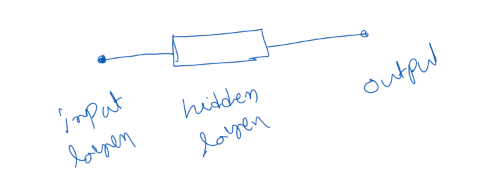

* **কীভাবে কাজ করে:** যদি বাক্যটি হয় "movie was good", ANN এই তিনটি শব্দের ভেক্টরকে ইনপুট লেয়ারে একসাথে রিসিভ করবে। এর কাছে সময়ের কোনো ধারণা নেই। এটি পুরো বাক্যকে একটি একক ডেটা পয়েন্ট হিসেবে দেখে।

### 2. The RNN Approach (Time Steps)
RNN-এর স্ট্রাকচার দেখতে অনেকটা ANN-এর মতোই মনে হলেও, ইনপুট দেওয়ার স্টাইল সম্পূর্ণ ভিন্ন। RNN পুরো ডেটা একসাথে নেয় না, সে ডেটা নেয় **Time Step** বা সময়ের ভিত্তিতে।

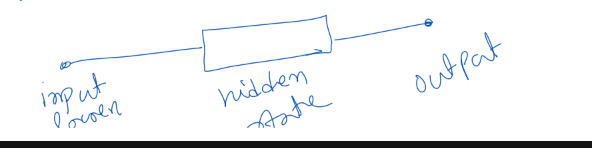

* **কীভাবে কাজ করে:** যখন আমরা $x_1$ ("movie was good") বাক্যটি ইনপুট দেব, তখন RNN ধাপে ধাপে এটি প্রসেস করবে:
  * **$t_1$ (Time 1):** ইনপুট নেবে শুধু `movie`
  * **$t_2$ (Time 2):** ইনপুট নেবে শুধু `was`
  * **$t_3$ (Time 3):** ইনপুট নেবে শুধু `good`

**💡 Key Takeaway:** ANN সব ডেটা একসাথে দেখে (Parallel Processing), কিন্তু RNN একটি সিকোয়েন্স মেনে সময়ের ভিত্তিতে একেকটি শব্দ প্রসেস করে (Sequential Processing)।

## 🚀 What's Next?
যেহেতু RNN একেকটি শব্দ একেক সময়ে নিচ্ছে, তাই $t_3$-তে এসে তার তো ভুলে যাওয়ার কথা যে $t_1$-এ কী শব্দ ছিল! কিন্তু সে ভোলে না। কারণ তার ভেতরে একটি **Memory** বা **Hidden State** আছে। আমাদের পরবর্তী কাজ হবে এই **Hidden State** কীভাবে কাজ করে তা গভীরভাবে বোঝা।


# **State (Memory)-এর সাপেক্ষে RNN কীভাবে কাজ করে**

## 🧠 State বা Memory-এর ধারণা
এর আগে আমরা জেনেছি যে ANN পুরো ইনপুটটা একসাথে নিয়ে নেয়, কিন্তু RNN ইনপুট নেয় Time Step ($t_1, t_2...$) এর ওপর ভিত্তি করে। এখন আমরা দেখব এই Time Step-গুলো কীভাবে একটি "State" বা মেমরি তৈরি করে।

RNN-এর মূল আর্কিটেকচারে **State** বা মেমরি তখনই তৈরি হয়, যখন কোনো নিউরনের আউটপুট ঘুরে আবার নিজের কাছেই ইনপুট হিসেবে ফিরে আসে (যাকে Feedback Loop বলে)।

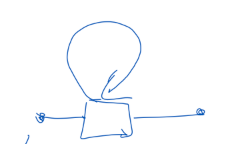

## 📝 ধাপে ধাপে Context তৈরি (Step-by-Step Context Building)
যদি আমরা "movie was not good" বাক্যটা নিয়ে চিন্তা করি, তাহলে প্রতিটি Time Step-এ মেমরি কীভাবে আপডেট হয় তা নিচের টেবিল থেকে বোঝা যায়:

| Time Step | বর্তমান শব্দ | Hidden State (Memory) কী করছে | মডেল যতটুকু অর্থ বুঝল |
| :--- | :--- | :--- | :--- |
| **$t_1$** | movie | "movie" মনে রেখেছে | movie |
| **$t_2$** | was | আগের মেমরির সাথে "was" যোগ করেছে | movie was |
| **$t_3$** | not | আগের মেমরির সাথে নেগেটিভ অর্থ যোগ করেছে | movie was not |
| **$t_4$** | good | আগের মেমরির সাথে "good" যোগ করেছে | পুরো বাক্যের অর্থ যে নেগেটিভ, তা বুঝতে পেরেছে |

## 🔬 Hidden Layer-এর ভেতরের মেকানিজম
আমরা যদি একটু গভীরভাবে চিন্তা করি যে আসলে নিউরাল নেটওয়ার্কের ভেতরে কী হচ্ছে, তাহলে আমাদের Vectorization-এর কনসেপ্টটা লাগবে।

ধরি, আমাদের Vocabulary সাইজ = 5 (movie, was, good, bad, not)। তাহলে আমাদের ইনপুট ভেক্টর হবে 5 সাইজের। এবং ধরলাম আমাদের Hidden State-এ **৩টি নিউরন** আছে।

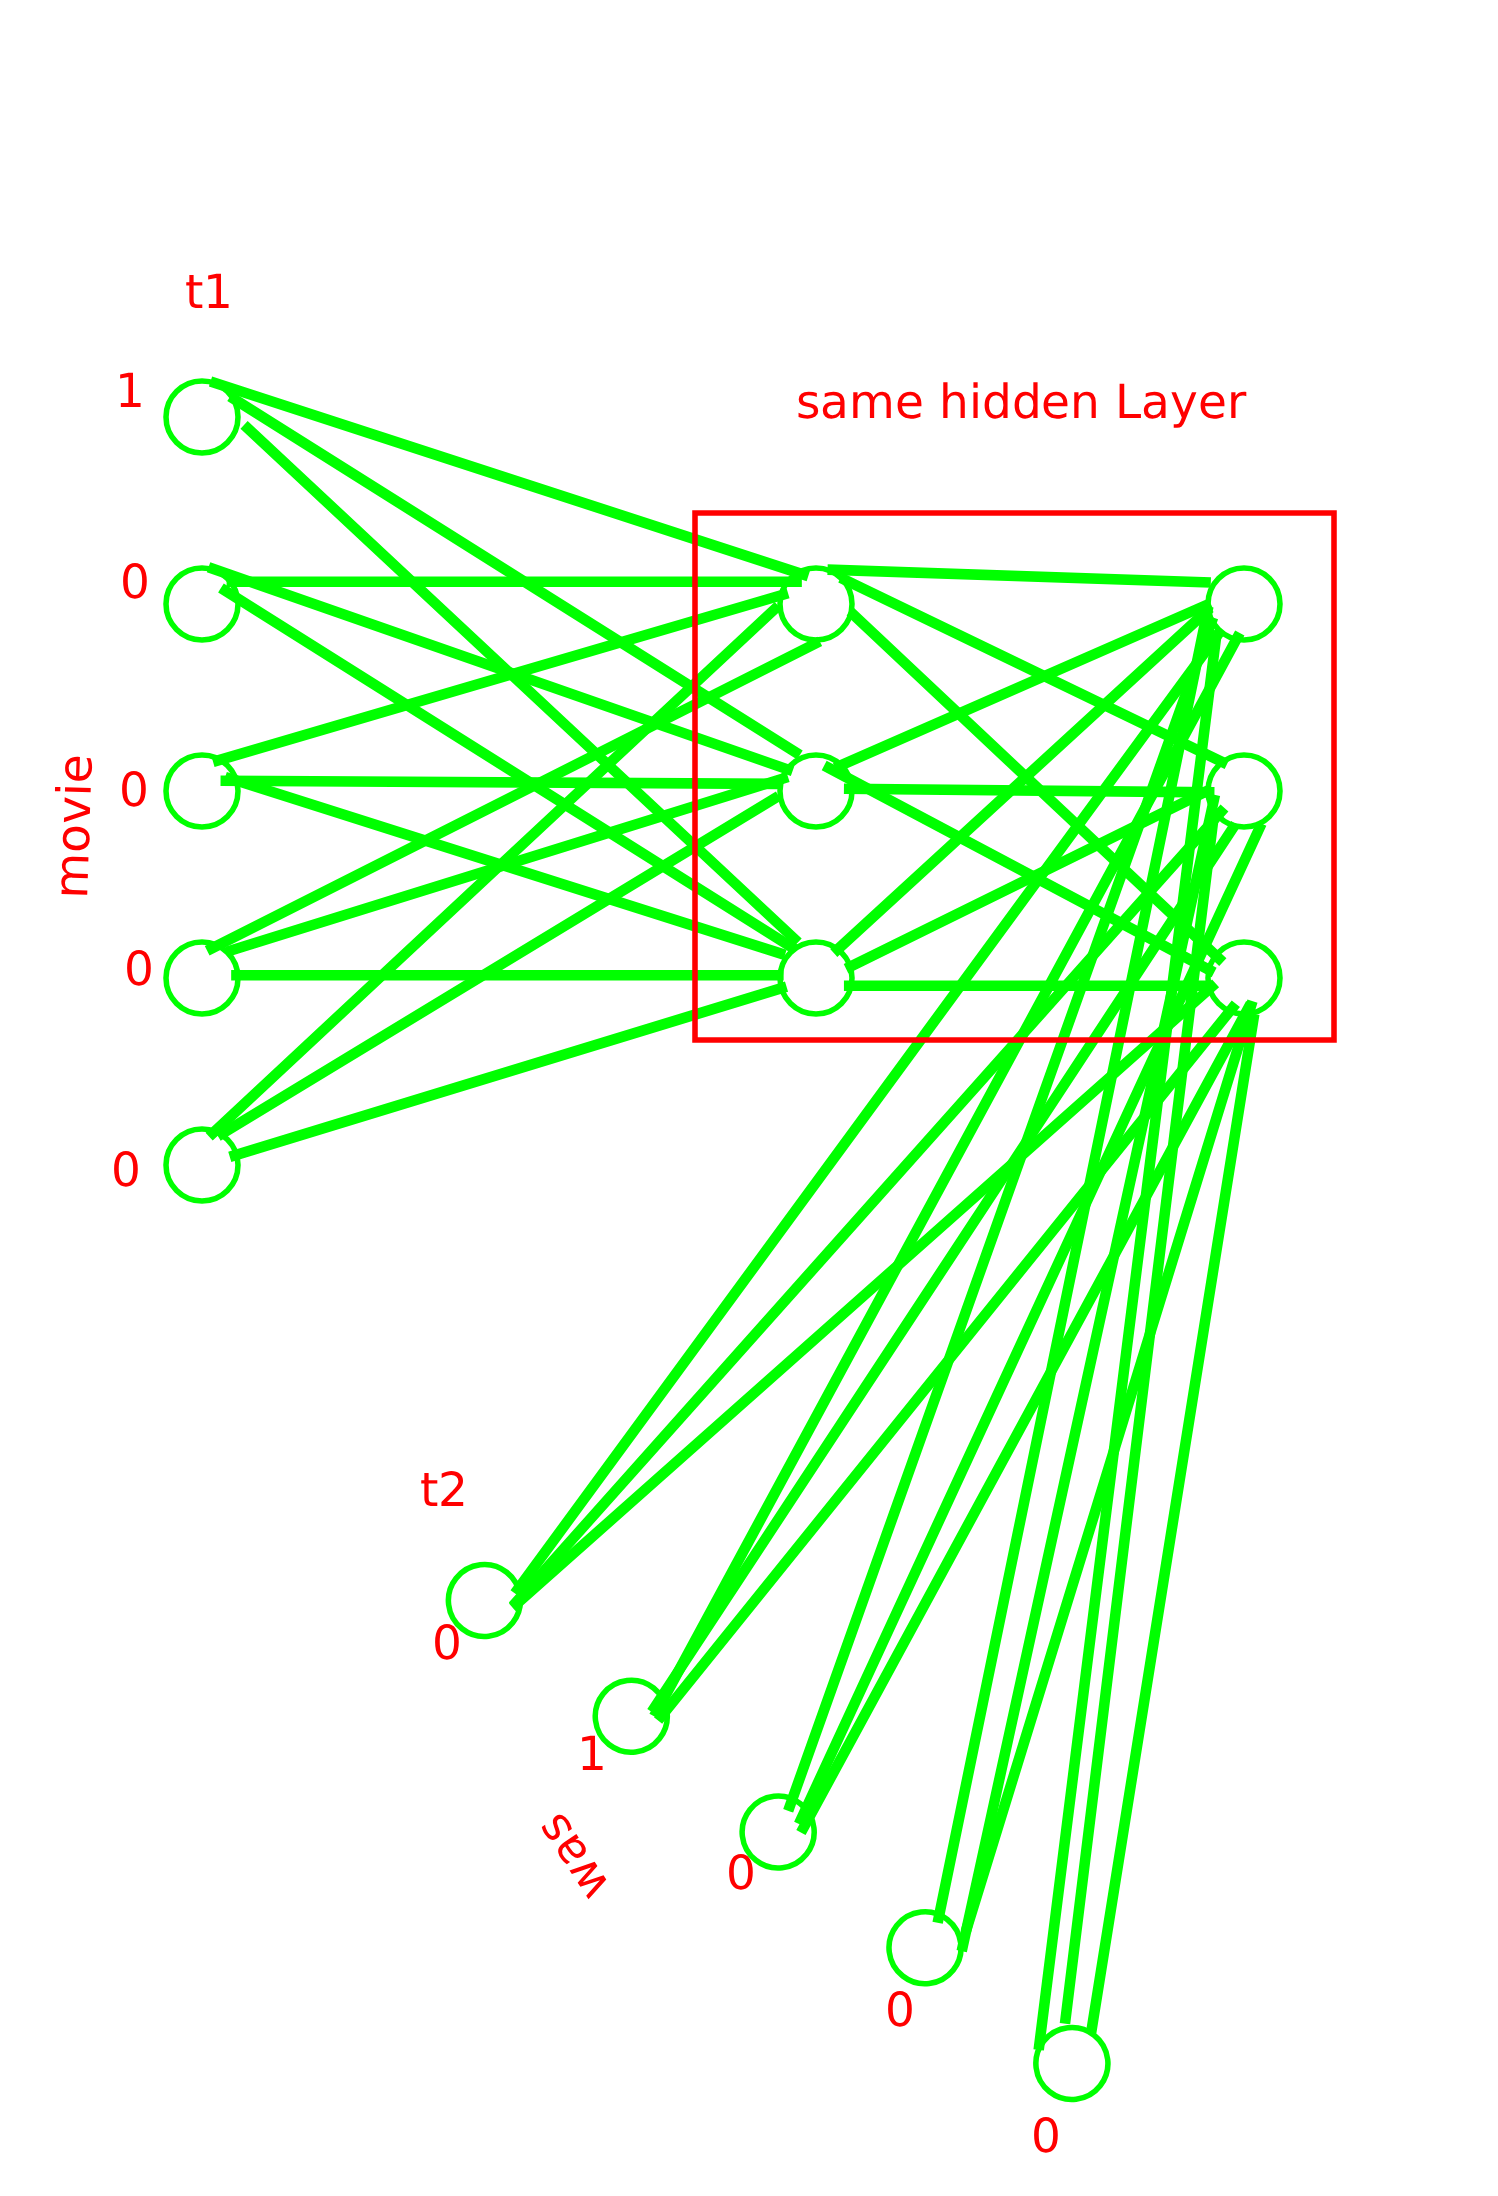

### Time Step $t_1$ ("movie"):
* **ইনপুট:** "movie"-এর One-hot vector `[1, 0, 0, 0, 0]` আমরা ইনপুট হিসেবে দিলাম।
* **কানেকশন:** এটি ANN-এর মতোই Fully connected layer হবে। ইনপুটের ৫টি নোড থেকে কানেকশন হিডেন লেয়ারের ৩টি নিউরনের সাথেই যুক্ত থাকবে।
* **আউটপুট:** এই ৩টি নিউরন থেকে একটি আউটপুট বের হবে।

### 🔄 The Magic of Recurrence (লুপ ব্যাক করা):
এটাই আসল ম্যাজিক! হিডেন স্টেটের নিউরন থেকে যে আউটপুট বের হলো, সেটি শুধু সামনের দিকে (আউটপুট লেয়ারে) যাবে না, বরং সেটি **নিজের কাছেই আবার ফিরে আসবে**। শুধু নিজের কাছে না, হিডেন লেয়ারের একটি নিউরনের আউটপুট বাকি অন্য নিউরনগুলোর কাছেও যাবে। এটাই হলো আগের স্টেটের "Memory" বা স্মৃতি।

### Time Step $t_2$ ("was"):
* **নতুন ইনপুট:** এখন আমরা ২য় শব্দ "was"-এর ভেক্টর `[0, 1, 0, 0, 0]` ইনপুট দিলাম। এগুলোও হিডেন স্টেটের ৩টি নিউরনের সাথে যুক্ত হবে।
* **ডেটা যুক্ত হওয়া (Merging):** এখন হিডেন লেয়ারের ৩টি নিউরন **একসাথে ২টি জিনিস** গ্রহণ করবে:
  ১. Current Input (এখনকার শব্দ "was")।
  ২. Previous Hidden State (আগের শব্দ "movie" থেকে আসা মেমরি লুপ)।
* **আপডেট:** নিউরনগুলো এখন আগের ইনফরমেশনের সাথে নতুন ইনফরমেশন যোগ করে নিজেদের আপডেট করবে।

এভাবে $t_3, t_4...$ ধাপগুলো চলতে থাকবে এবং শেষ শব্দের পর আমরা একটি ফাইনাল আউটপুট বা সেন্টিমেন্ট পাব। এভাবেই মূলত ওয়েইট (Weight) আপডেট হয় এবং RNN একটি সিকোয়েন্সের অর্থ বুঝতে পারে।

# **Core Example: Initial State & Parameter Calculation**

## 🏁 t1 সময়ে Initial State (শুরুর মেমরি)
RNN মূলত কাজ শুরু করে বর্তমান ইনপুট (Current State) এবং আগের মেমরি (Previous Memory) দিয়ে। কিন্তু প্রশ্ন হলো, **t1 সময়ে (যখন একদম প্রথম ইনপুট দেওয়া হচ্ছে) আগের মেমরি কোথা থেকে আসবে?**
* **উত্তর:** যেহেতু শুরুতে কোনো অতীতের ইনফরমেশন থাকে না, তাই আমরা t1 সময়ের জন্য একটি Initial Hidden State ধরে নিই। কোড করার সময় মডেলকে নিউট্রাল রাখার জন্য এই শুরুর মেমরিকে সাধারণত Random ভ্যালু না দিয়ে **সবগুলো জিরো (Zeros)** দিয়ে ইনিশিয়ালাইজ করা হয় (যেমন: `[0, 0, 0]`)।

## 🧮 Parameter Calculation (প্যারামিটার হিসাব)
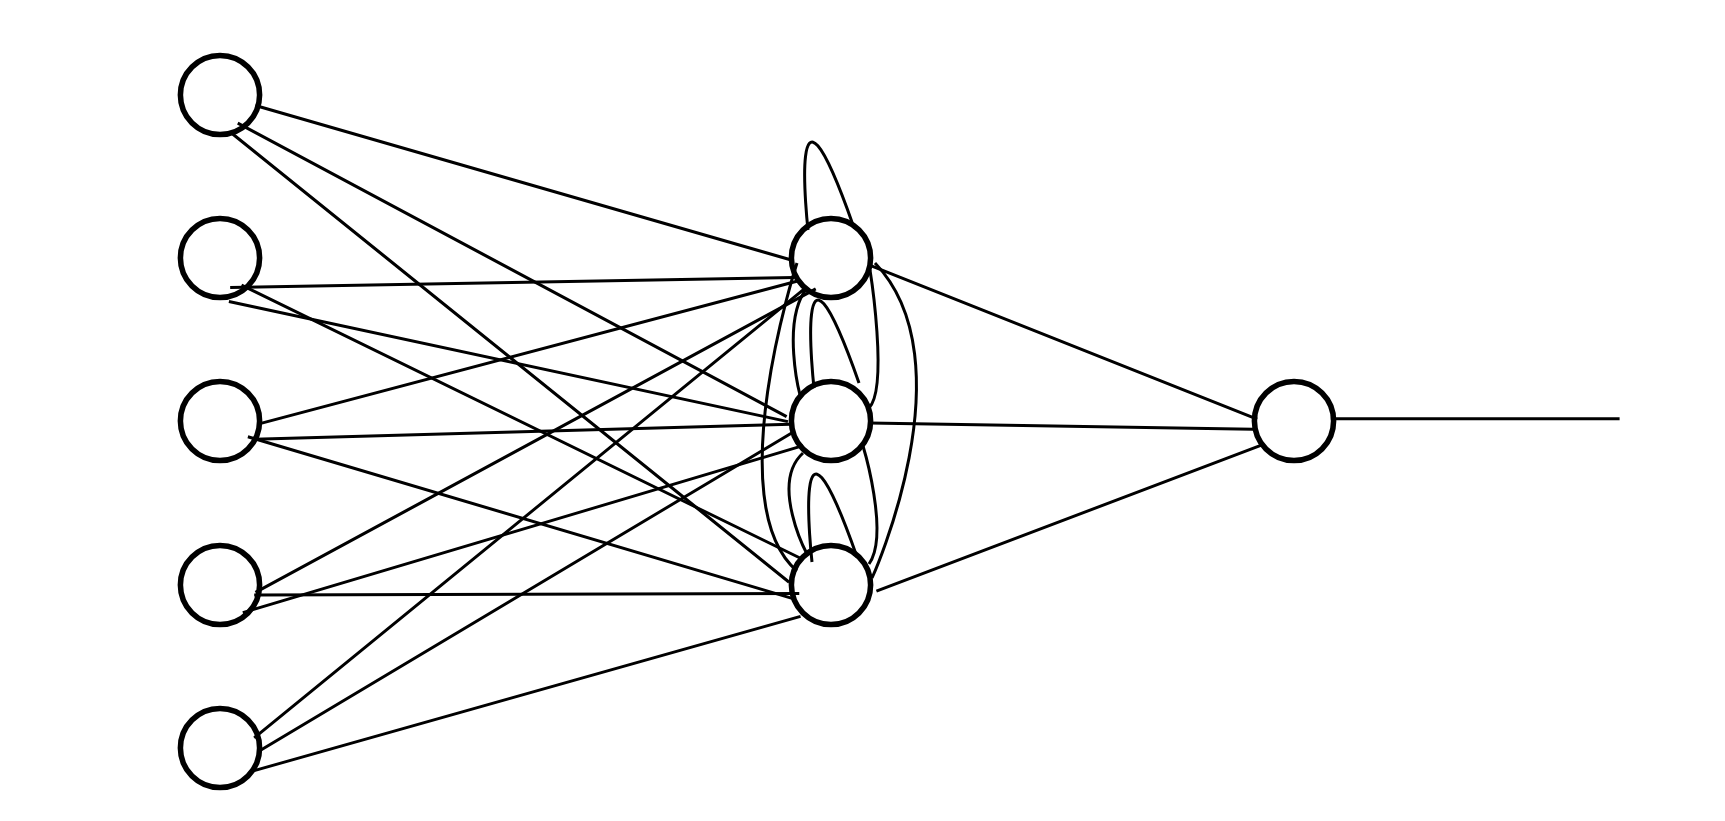

**আমাদের আর্কিটেকচার:**
* Input Nodes = 5
* Hidden Nodes = 3
* Output Node = 1

**১. Input থেকে Hidden Layer:**
* **Weights:** প্রতি ইনপুট নোড ৩টি হিডেন নোডের সাথে যুক্ত। তাই 5 x 3 = 15 টি Weights.
* **Bias:** হিডেন লেয়ারের ৩টি নোডের জন্য 3 টি Bias.
* **মোট =** 15 + 3 = 18

**২. Hidden থেকে Output Layer:**
* **Weights:** ৩টি হিডেন নোড ১টি আউটপুট নোডের সাথে যুক্ত। তাই 3 x 1 = 3 টি Weights.
* **Bias:** আউটপুট লেয়ারের ১টি নোডের জন্য 1 টি Bias.
* **মোট =** 3 + 1 = 4

**৩. Hidden থেকে Hidden Layer (Recurrent / Loop):**
* **Weights:** হিডেন লেয়ারের ৩টি নোড নিজেদের এবং একে অপরের সাথে যুক্ত। তাই 3 x 3 = 9 টি Weights.
* **Bias:** লুপের জন্য আরও 3 টি Bias (PyTorch মূলত এভাবেই ইনপুট এবং লুপের জন্য আলাদা Bias ধরে হিসাব করে)।
* **মোট =** 9 + 3 = 12

**সর্বমোট প্যারামিটার:**
* Total Parameters = 18 + 4 + 12 = **34**

# **Code Example**


## **Complete RNN Pipeline: Code Walkthrough**
এই সম্পূর্ণ কোডটিকে আমরা কাজের ধাপ অনুযায়ী **৪টি মূল অংশে** ভাগ করে বুঝতে পারি:

## 📦 অংশ ১: ইমপোর্ট এবং ক্লাস তৈরি (Imports & Setup)

```python
import torch
import torch.nn as nn

class RNNModel(nn.Module):

```

* **`import torch...`:** PyTorch-এর মূল লাইব্রেরি এবং নিউরাল নেটওয়ার্ক মডিউল (`nn`) ইমপোর্ট করা হয়েছে।
* **`class RNNModel(nn.Module):`** এখানে আমরা আমাদের মডেলের ব্লু-প্রিন্ট তৈরি করছি। PyTorch-এ যেকোনো মডেল বানাতে হলে তাকে অবশ্যই `nn.Module`-কে ইনহেরিট (Inherit) করতে হয়, যাতে PyTorch বুঝতে পারে এটি একটি নিউরাল নেটওয়ার্ক।

---

## 🏗️ অংশ ২: লেয়ার ডিফাইন করা (`__init__` মেথড)

এখানে আমরা বলে দিই আমাদের মডেলের ভেতর কী কী উপাদান বা লেয়ার থাকবে।

```python
  def __init__(self):
    super(RNNModel, self).__init__() # PyTorch-এর মূল মডিউলে মডেলটিকে রেজিস্টার করা
    
    self.rnn = nn.RNN(input_size=5, hidden_size=3, batch_first=True)
    self.fc = nn.Linear(3,1)
    self.sigmoid = nn.Sigmoid()

```

* **`self.rnn`:** এটি আমাদের মূল মেমরি ব্লক বা হিডেন লেয়ার।
* `input_size=5`: আমাদের প্রতিটি শব্দের ভেক্টরের সাইজ ৫।
* `hidden_size=3`: মেমরি ধরে রাখার জন্য হিডেন স্টেটে ৩টি নিউরন আছে।
* `batch_first=True`: ইনপুট দেওয়ার সময় ডেটার শেপ হবে `(Batch, Sequence, Features)`।


* **`self.fc`:** Fully Connected (Linear) লেয়ার। এটি হিডেন লেয়ারের ৩টি আউটপুটকে ডিসিশন নেওয়ার জন্য ১টি আউটপুটে নামিয়ে আনবে।
* **`self.sigmoid`:** অ্যাক্টিভেশন ফাংশন। এটি ফাইনাল আউটপুটকে 0 থেকে 1-এর মধ্যে একটি প্রোবাবিলিটিতে (Probability) রূপান্তর করবে (সেন্টিমেন্ট পজিটিভ নাকি নেগেটিভ তা বোঝার জন্য)।

---

## 🚀 অংশ ৩: ডেটা ফ্লো বা ফরোয়ার্ড পাস (`forward` মেথড)

এখানে ইনপুট ডেটা (`x`) লেয়ারগুলোর ভেতর দিয়ে কীভাবে ধাপে ধাপে প্রসেস হয়ে ফাইনাল আউটপুটে যাবে, তার রাস্তা বলে দেওয়া হয়েছে।

```python
  def forward(self, x):
    out, _ = self.rnn(x)
    out = out[:,-1,:]
    out = self.fc(out)
    out = self.sigmoid(out)
    return out

```

* **`out, _ = self.rnn(x)`:** ডেটা RNN-এ প্রবেশ করল। এটি সবগুলো টাইম-স্টেপের আউটপুট `out`-এ জমা রাখল এবং শেষের মেমরিটা `_` (আন্ডারস্কোর) দিয়ে ইগনোর করল।
* **`out = out[:, -1, :]` (সবচেয়ে গুরুত্বপূর্ণ লাইন):** যেহেতু এটি Sentiment Analysis, আমাদের শুধু বাক্যের একদম শেষের অর্থটা দরকার। তাই বহুমাত্রিক স্লাইসিং ব্যবহার করে সবগুলো ব্যাচ (`:`) থেকে একদম শেষের টাইম-স্টেপ (`-1`)-এর ৩টি হিডেন ভ্যালু (`:`) কেটে নেওয়া হলো।
* **`out = self.fc(out)`:** শেষের মেমরি ভ্যালুগুলো লিনিয়ার লেয়ারে গিয়ে ১টি ভ্যালুতে পরিণত হলো।
* **`out = self.sigmoid(out)`:** ভ্যালুটি সিগময়েড পার হয়ে 0 বা 1-এর কাছাকাছি চলে এলো।
* **`return out`:** মডেল তার চূড়ান্ত প্রেডিকশন দিয়ে দিল।

---

## 🔍 অংশ ৪: মডেল ইনিশিয়ালাইজেশন এবং প্যারামিটার ভেরিফিকেশন

কোডের এই শেষ অংশটি হলো ডিবাগিং এবং চেকলিস্ট। মডেলকে ডেটা দেওয়ার আগে সে ভেতরে ঠিকমতো তৈরি হয়েছে কি না, তা এখানে মাপা হচ্ছে।

```python
model = RNNModel()

```

* ব্লু-প্রিন্ট (`RNNModel` ক্লাস) থেকে একটি আসল অবজেক্ট বা ইনস্ট্যান্স তৈরি করা হলো, যার নাম দেওয়া হলো `model`।

```python
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(total_params)

```

* এটি মডেলের ভেতর যতগুলো শেখার যোগ্য (Trainable) ওয়েইট এবং বায়াস আছে, তার মোট সংখ্যা গুনে বের করে। এর আউটপুট আসবে **34**।

```python
print(f"\nTrainable parameters breakdown:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"  {name}: {param.numel()} params {list(param.shape)}")

```

* এটি হলো মডেলের এক্স-রে রিপোর্ট। এটি লেয়ার বাই লেয়ার ভেঙে দেখায় যে ৩৪টি প্যারামিটার ঠিক কোথায় কীভাবে আছে এবং তাদের ম্যাট্রিক্সের আকার কেমন:
* **`rnn.weight_ih_l0` (15 params):** ইনপুট (5) থেকে হিডেন (3)-এ যাওয়ার ওয়েইট। শেপ `[3, 5]`।
* **`rnn.weight_hh_l0` (9 params):** হিডেনের মেমরি লুপ। ৩টি নিউরন নিজেদের সাথে যুক্ত। শেপ `[3, 3]`।
* **`rnn.bias_ih_l0` ও `rnn.bias_hh_l0` (3 + 3 params):** ইনপুট এবং লুপের জন্য আলাদা ৩টি করে মোট ৬টি বায়াস।
* **`fc.weight` (3 params):** হিডেন (3) থেকে আউটপুট (1)-এ যাওয়ার ওয়েইট। শেপ `[1, 3]`।
* **`fc.bias` (1 params):** আউটপুট লেয়ারের নিজস্ব ১টি বায়াস।

In [2]:
import torch
import torch.nn as nn

In [3]:
class RNNModel(nn.Module):
  def __init__(self):
    # register
    super(RNNModel, self).__init__()
    self.rnn = nn.RNN(input_size=5, hidden_size=3, batch_first=True)
    self.fc = nn.Linear(3,1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    out, _ = self.rnn(x)
    out = out[:,-1,:]
    out = self.fc(out)
    out = self.sigmoid(out)
    return out


In [4]:
model = RNNModel()

In [5]:
model

RNNModel(
  (rnn): RNN(5, 3, batch_first=True)
  (fc): Linear(in_features=3, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [8]:
for p in model.parameters():
  print(p.numel())

15
9
3
3
3
1


In [ ]:
# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(total_params)


34


### 🔍 কোডের ব্যবচ্ছেদ (Step-by-Step Breakdown)

**১. `model.parameters()` (সবগুলো ম্যাট্রিক্স বের করা):**

* এটি তোমার পুরো `RNNModel`-এর ভেতরে ঢুকে যতগুলো ওয়েইট (Weight) এবং বায়াস (Bias) লেয়ার আছে, সেগুলোর একটি লিস্ট বা কালেকশন বের করে আনে।

**২. `for p in ...` (লুপ চালানো):**

* এটি ওই লিস্টের প্রতিটি ওয়েইট ম্যাট্রিক্সের (যার নাম আমরা `p` বা parameter দিয়েছি) ওপর দিয়ে একটা লুপ চালায়। অর্থাৎ, সে এক এক করে প্রতিটি লেয়ারের কাছে যায়।

**৩. `if p.requires_grad` (ফিল্টার করা):**

* লুপ চালানোর সময় সে একটি শর্ত (Condition) চেক করে। `requires_grad` মানে হলো **"এই লেয়ারটি কি শেখার যোগ্য (Trainable)?"** * যদি লেয়ারটি ফ্রিজ (Freeze) করা থাকে, তবে তার `requires_grad` হবে `False` এবং এই কোড তাকে সাথে সাথে বাদ দিয়ে দেবে। শুধু যে লেয়ারগুলোর ভ্যালু আপডেট হবে, সেগুলোকে সে পরের ধাপে পাঠাবে।

**৪. `p.numel()` (সংখ্যা গোনা):**

* `numel` মানে হলো **Number of Elements**।
* ফিল্টার হয়ে আসা প্রতিটি ম্যাট্রিক্সের ভেতরে ঠিক কয়টি সংখ্যা বা ভ্যালু আছে, এটি তা গুনে বের করে।
* যেমন: তোমার `rnn.weight_ih_l0` লেয়ারের আকার ছিল `[3, 5]`। `numel()` এখানে গিয়ে হিসাব করবে ৩ x ৫ = **১৫**।

**৫. `sum(...)` (সব যোগ করা):**

* সবশেষে, এই `sum` ফাংশনটি প্রতিটি লেয়ার থেকে পাওয়া `numel()`-এর সংখ্যাগুলোকে একসাথে যোগ করে দেয়।
* (যেমন: ১৫ + ৯ + ৩ + ৩ + ৩ + ১ = **৩৪**)।

---

### 🏭 বাস্তব জীবনের অ্যানালজি (কারখানা)

ধরে নাও তোমার মডেলটি একটি বড় কারখানা:

* `parameters()`: কারখানার সবগুলো মেশিন।
* `requires_grad`: তুমি শুধু ওই মেশিনগুলো বেছে নিচ্ছ যেগুলো এখনো ঠিকমতো সেট করা হয়নি (যাদের টিউনিং দরকার)।
* `numel()`: তুমি ওই নির্দিষ্ট মেশিনগুলোর ভেতরে কয়টি করে নাট-বল্টু আছে তা গুনছ।
* `sum()`: সবশেষে সব মেশিনের নাট-বল্টুর সংখ্যা একসাথে যোগ করে বলছ, "আমার কারখানায় মোট ৩৪টি নাট-বল্টু টাইট দিতে হবে!"

In [ ]:
# Count trainable parameters
print(f"\nTrainable parameters breakdown:")

for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"  {name}: {param.numel()} params {list(param.shape)}")

print(f"\nTotal Trainable Parameters: {total_params}")


Trainable parameters breakdown:
  rnn.weight_ih_l0: 15 params [3, 5]
  rnn.weight_hh_l0: 9 params [3, 3]
  rnn.bias_ih_l0: 3 params [3]
  rnn.bias_hh_l0: 3 params [3]
  fc.weight: 3 params [1, 3]
  fc.bias: 1 params [1]

Total Trainable Parameters: 34


### 🔬 কোডের ব্যবচ্ছেদ (Code Breakdown)

**১. `model.named_parameters()`:**
আগের কোডে শুধু `parameters()` ছিল, যা লুপের ভেতরে শুধু ভ্যালু বা টেন্সর দিত। কিন্তু `named_parameters()` প্রতিটি প্যারামিটারের **নাম (name)** এবং তার **টেন্সর (param)**—উভয়ই একসাথে ফেরত দেয়। এতে আমরা বুঝতে পারি কোন ওয়েইট বা বায়াসটা ঠিক কোন লেয়ারের।

**২. `list(param.shape)`:**
এটি ওই নির্দিষ্ট প্যারামিটারের ডাইমেনশন বা আকার দেখায়। যেমন: `[3, 5]` মানে হলো এই ওয়েইট ম্যাট্রিক্সটিতে ৩টি সারি (Row) এবং ৫টি কলাম (Column) আছে।

---

### 📊 আমাদের RNN মডেলে এর আউটপুট কেমন হবে?

আমরা যদি আমাদের আগের তৈরি করা `RNNModel`-এর ওপর এই কোডটি রান করি, তাহলে কনসোলে ঠিক নিচের মতো একটি চমৎকার আউটপুট প্রিন্ট হবে। খেয়াল করে দেখো, এটি তোমার খাতায় করা হিসাবের সাথে কতটা নিখুঁতভাবে মিলে যায়:

```text
Trainable parameters breakdown:
  rnn.weight_ih_l0: 15 params [3, 5]
  rnn.weight_hh_l0: 9 params [3, 3]
  rnn.bias_ih_l0: 3 params [3]
  rnn.bias_hh_l0: 3 params [3]
  fc.weight: 3 params [1, 3]
  fc.bias: 1 params [1]

Total Trainable Parameters: 34

```

### 💡 আউটপুট থেকে কী কী শিখলাম? (PyTorch Naming Secrets)

PyTorch নিজে থেকে লেয়ারগুলোর যে নাম দিয়েছে, তা খেয়াল করলে কনসেপ্ট আরও পরিষ্কার হয়ে যাবে:

* **`rnn.weight_ih_l0` (15 params):** * **ih** মানে হলো **Input-to-Hidden**। আমাদের ইনপুট ছিল ৫ সাইজের, আর হিডেন নিউরন ৩টি। তাই এর শেপ `[3, 5]` এবং মোট ওয়েইট ৩ x ৫ = ১৫টি। (`l0` মানে Layer 0 বা প্রথম লেয়ার)।
* **`rnn.weight_hh_l0` (9 params):**
* **hh** মানে হলো **Hidden-to-Hidden** (আমাদের সেই মেমরির লুপ)। ৩টি হিডেন নিউরন নিজেদের সাথে যুক্ত, তাই শেপ `[3, 3]` এবং মোট ওয়েইট ৩ x ৩ = ৯টি।


* **`rnn.bias_ih_l0` ও `rnn.bias_hh_l0` (3 + 3 params):**
* মনে আছে তুমি খাতায় হিসাব করার সময় ইনপুটের জন্য ৩টি এবং লুপের জন্য আলাদা ৩টি বায়াস ধরেছিলে? PyTorch ঠিক এভাবেই `bias_ih` এবং `bias_hh` নামে দুটো আলাদা বায়াস তৈরি করে!


* **`fc.weight` ও `fc.bias` (3 + 1 params):**
* আমাদের Fully Connected লেয়ারের কানেকশন। ৩টি হিডেন থেকে ১টি আউটপুটে যাওয়ার ওয়েইট ৩টি (শেপ `[1, 3]`) এবং আউটপুট লেয়ারের নিজস্ব বায়াস ১টি।



---

### 🎯 বাস্তবে এই কোডটি কেন আরও বেশি কাজের?

১. **Shape Debugging (সবচেয়ে বড় লাইফসেভার):** PyTorch-এ কোড করার সময় ৯৯% এরর (Error) হয় ম্যাট্রিক্সের শেপ না মেলার কারণে (যেমন: 5 সাইজের জায়গায় 4 সাইজের ইনপুট চলে যাওয়া)। এই কোডটি রান করলে তুমি লেয়ার বাই লেয়ার দেখতে পাচ্ছো কোথায় ম্যাট্রিক্সের আকার কেমন আছে। কোথাও ভুল থাকলে তুমি নাম আর শেপ দেখেই ধরে ফেলতে পারবে।
২. **Fine-Tuning ভেরিফিকেশন:** তুমি যদি কোনো নির্দিষ্ট লেয়ার ফ্রিজ (Freeze) করে দাও (যেমন: Transfer Learning-এর সময়), তবে এই লিস্টে সেই লেয়ারের নাম আর প্রিন্ট হবে না। ফলে তুমি ১০০% নিশ্চিত হতে পারবে যে ফ্রিজ করাটা ঠিকমতো কাজ করছে।

এই কোডটি মূলত একজন প্রফেশনাল আর্কিটেক্টের চেকলিস্ট। মডেলকে ট্রেইনিংয়ে পাঠানোর আগে সবকিছু ঠিক আছে কি না, তা যাচাই করার জন্যই এটি ব্যবহার করা হয়। কনসেপ্টটি কি এখন পরিষ্কার হয়েছে?

In [1]:
import torch

# শেপ: [Batch=2, Sequence=3, Feature=2]
out = torch.tensor([

    # ---------------- ব্যাচ ১ (১ম বাক্য) ----------------
    [
        [1, 2],   # t1 (১ম শব্দ)
        [3, 4],   # t2 (২য় শব্দ)
        [5, 6]    # t3 (৩য় শব্দ বা শেষ শব্দ)
    ],

    # ---------------- ব্যাচ ২ (২য় বাক্য) ----------------
    [
        [7, 8],   # t1 (১ম শব্দ)
        [9, 10],  # t2 (২য় শব্দ)
        [11, 12]  # t3 (৩য় শব্দ বা শেষ শব্দ)
    ]
])

In [2]:
print(out[0, :, :])

tensor([[1, 2],
        [3, 4],
        [5, 6]])


In [8]:
print(out[1, :, :])

tensor([[ 7,  8],
        [ 9, 10],
        [11, 12]])


In [6]:
print(out[1, :, : ])

tensor([[ 7,  8],
        [ 9, 10],
        [11, 12]])


In [17]:
out[:,-1,:]

tensor([[ 5,  6],
        [11, 12]])

# 📌 ক্ল্যারিফিকেশন নোট: RNN প্যারামিটার ক্যালকুলেশন (PyTorch বনাম Keras/TensorFlow)

আমরা যখন মডেলের প্যারামিটার (Weights & Biases) হিসাব করছিলাম, তখন আমাদের মোট প্যারামিটার এসেছিল **৩৪টি**। কিন্তু তাত্ত্বিকভাবে (Theoretically) এবং **Keras/TensorFlow** ফ্রেমওয়ার্কে এই একই আর্কিটেকচারের প্যারামিটার হবে **৩১টি**।

এর পেছনের মূল কারণ হলো **Bias (বায়াস)** কীভাবে মেমরিতে স্টোর করা হচ্ছে তার পার্থক্য:

**১. ম্যাথমেটিক্যাল থিওরি ও Keras (৩১টি প্যারামিটার):**
তাত্ত্বিকভাবে ফরোয়ার্ড প্রোপাগেশনের সময় ইনপুট ওয়েইট ($W_x$) এবং হিডেন ওয়েইট ($W_h$)-এর গুণফলের পর একটিমাত্র কম্বাইন্ড বা কমন বায়াস ($b$) যোগ করলেই কাজ হয়ে যায়।

* ইনপুট ওয়েইট: ৩ x ৫ = ১৫
* হিডেন ওয়েইট: ৩ x ৩ = ৯
* **কমন বায়াস (Bias): ৩** (শুধুমাত্র হিডেন নিউরনের সংখ্যার সমান)
* *RNN লেয়ারের মোট:* ২৭টি। (এর সাথে লিনিয়ার লেয়ারের ৪টি যোগ করলে মোট **৩১টি**)।

**২. PyTorch-এর ইন্টারনাল ডিজাইন (৩৪টি প্যারামিটার):**
PyTorch ইন্টারনাল অপ্টিমাইজেশন এবং দ্রুত ক্যালকুলেশনের (বিশেষ করে cuDNN লাইব্রেরির সাথে সামঞ্জস্য রাখার) জন্য ইনপুট এবং হিডেন—উভয় কানেকশনের জন্য আলাদা আলাদা বায়াস মেমরিতে স্টোর করে।

* ইনপুট ওয়েইট: ৩ x ৫ = ১৫
* হিডেন ওয়েইট: ৩ x ৩ = ৯
* **ইনপুটের জন্য বায়াস (`bias_ih`): ৩**
* **হিডেনের জন্য বায়াস (`bias_hh`): ৩**
* *RNN লেয়ারের মোট:* ৩০টি। (এর সাথে লিনিয়ার লেয়ারের ৪টি যোগ করলে মোট **৩৪টি**)।

**সারসংক্ষেপ:** আমরা যখন PyTorch ব্যবহার করব, তখন সেটি ইনপুট এবং হিডেন স্টেটের জন্য আলাদা আলাদা বায়াস কাউন্ট করবে। তবে ফরোয়ার্ড প্রোপাগেশনের মূল থিওরিতে এই দুটি বায়াস মূলত একত্রিত (Combine) হয়ে একটি বায়াস হিসেবেই কাজ করে।

---

# **Unrolled RNN (through time) diagram understanding**

![d295dfa0-667f-49e3-be6f-d64c7c731f1b.png](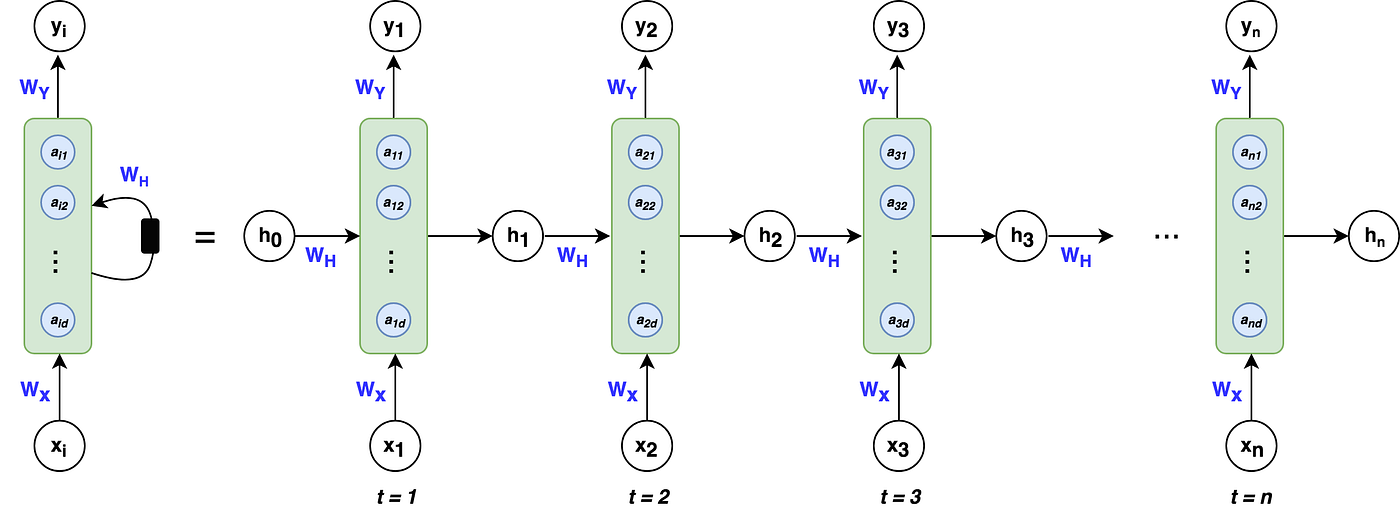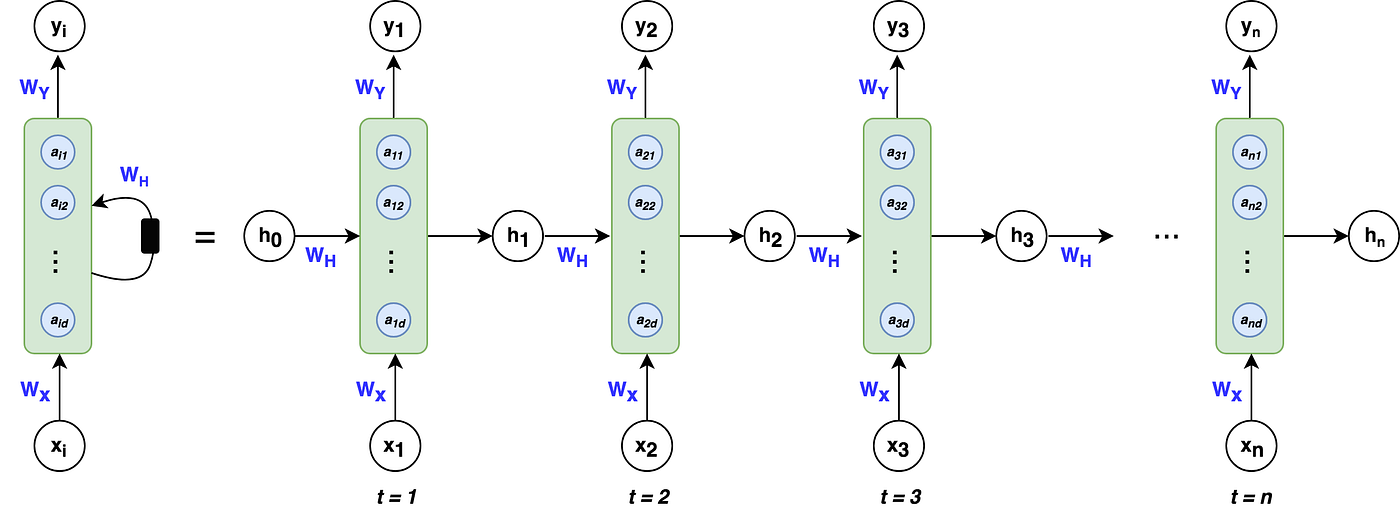)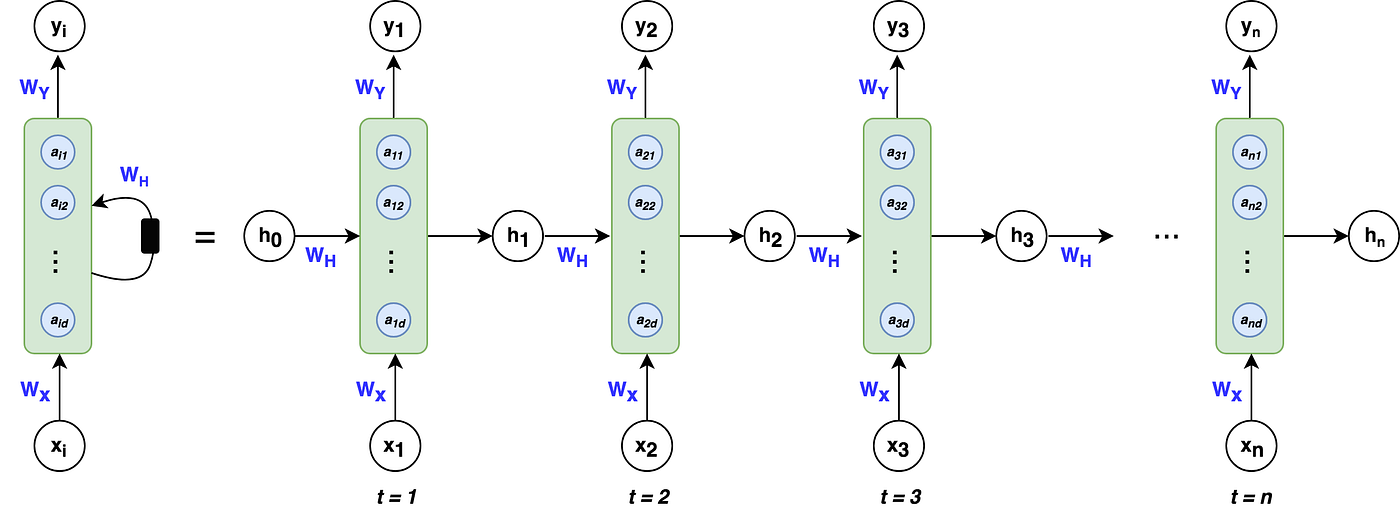

### 📦 ১. ছবির বাম পাশ (Folded বা গোটানো অবস্থা)

বাম পাশের অংশটি হলো একটি কমপ্যাক্ট বা গোটানো অবস্থা। তুমি যখন কোডে `self.rnn = nn.RNN(...)` লিখেছিলে, তখন মডেলটি ঠিক এই বাম পাশের বক্সটির মতোই তৈরি হয়েছিল।

* **$x_i$:** এটি হলো আমাদের ইনপুট শব্দ।
* **$W_X$:** ইনপুট থেকে হিডেন লেয়ারে যাওয়ার ওয়েইট।
* **সবুজ বক্স ($a_{i1}, a_{i2}...$):** এটি হলো আমাদের হিডেন লেয়ারের নিউরনগুলো (আমরা ৩টি নিউরন ধরেছিলাম)।
* **লুপ বা কালো বক্স ($W_H$):** এটাই সেই বিখ্যাত মেমরি কানেকশন! নিউরনের ডেটা প্রসেস হয়ে আবার নিজের কাছেই ফিরে আসছে।
* **$y_i$:** আউটপুট বা রেজাল্ট।

### 🎞️ ২. ছবির ডান পাশ (Unfolded বা বিছানো অবস্থা)

ডান পাশের অংশটি নতুন কিছু নয়, বরং এটি হলো বাম পাশের ওই একটিমাত্র বক্সকেই সময়ের ভিত্তিতে ($t=1, t=2, t=3...$) লম্বা করে খুলে (Unfold) দেখানো। আমাদের ব্রেইন ঠিক এভাবেই চিন্তা করে:

* **$t=1$ (প্রথম শব্দ "movie"):** $x_1$ হিসেবে "movie" ঢুকলো। পাশ থেকে $h_0$ (প্রাথমিক মেমরি, যা সাধারণত জিরো থাকে) আসলো। সবুজ বক্স প্রসেস করে নতুন মেমরি $h_1$ তৈরি করে সামনের ধাপে পাঠিয়ে দিলো।
* **$t=2$ (দ্বিতীয় শব্দ "was"):** $x_2$ হিসেবে "was" ঢুকলো। আর আগের ধাপ থেকে মেমরি $h_1$ আসলো। দুটো মিলে প্রসেস হয়ে তৈরি হলো নতুন মেমরি $h_2$।
* **এভাবে চলতে চলতে $t=n$:** একদম শেষ শব্দটা প্রসেস হয়ে চূড়ান্ত মেমরি $h_n$ (আমাদের উদাহরণে $t_4$) তৈরি হলো।

---

### 💡 এই ছবি থেকে শেখার মতো সবচেয়ে বড় ৩টি লেসন:

**১. Weight Sharing (সবচেয়ে ইম্পর্ট্যান্ট):**
ছবিতে খুব ভালোভাবে খেয়াল করো— প্রতিটি ধাপেই নীল রঙের **$W_X$, $W_H$ এবং $W_Y$** লেখা আছে। এর মানে হলো, তোমার বাক্য যত বড়ই হোক না কেন, মডেল কিন্তু নতুন কোনো ওয়েইট তৈরি করে না! আমাদের হিসাব করা সেই নির্দিষ্ট ওয়েইটগুলোই (৩৪টি প্যারামিটার) প্রতিটি ধাপে পুনরায় ব্যবহৃত (Share) হয়।

**২. $h$ মানে Hidden State:**
PyTorch-এ আমরা যে `_` (আন্ডারস্কোর) দিয়ে শেষের মেমরিটা ইগনোর করেছিলাম, সেটা আসলে ছবির এই একদম শেষের $h_n$।

**৩. ছবির আউটপুট বনাম আমাদের কোডের আউটপুট:**
ছবিতে দেখো প্রতিটি ধাপেই ওপরের দিকে আউটপুট ($y_1, y_2, y_3$) বের হচ্ছে। একে বলা হয় *Many-to-Many* আর্কিটেকচার (যেমন: Google Translate)। কিন্তু আমরা করছিলাম Sentiment Analysis (*Many-to-One*)। তাই আমাদের কোডে আমরা স্লাইসিং (`out[:, -1, :]`) করে মাঝখানের $y_1, y_2, y_3$-গুলোকে বাদ দিয়ে শুধু একদম শেষের আউটপুটটি ($y_n$) নিয়েছিলাম।


# **RNN Applications**


### 📝 ১. টেক্সট প্রসেসিং বা ল্যাঙ্গুয়েজ মডেলিং (NLP)

* **কাজ:** তুমি কী লিখতে যাচ্ছ, তা আগে থেকেই বুঝে পরের শব্দ বা বাক্যের পূর্বাভাস (Prediction) দেওয়া।
* **বাস্তব উদাহরণ:** মোবাইলে Gboard বা অন্য কোনো কিবোর্ডে টাইপ করার সময় ওপরে যে শব্দের সাজেশন আসে।
* **কীভাবে কাজ করে:** তুমি আগে কী কী শব্দ টাইপ করেছ, RNN তার মেমরিতে সেগুলো মনে রাখে এবং সেই প্যাটার্ন অনুযায়ী পরবর্তী সম্ভাব্য শব্দটি প্রেডিক্ট করে।

### 🌐 ২. মেশিন ট্রান্সলেশন (ভাষা অনুবাদ)

* **কাজ:** এক ভাষা থেকে অন্য ভাষায় নিখুঁত অনুবাদ করা।
* **বাস্তব উদাহরণ:** Google Translate।
* **কীভাবে কাজ করে:** তুমি ইনপুট দিলে "I love AI"। RNN শুধু আলাদা আলাদা শব্দের অর্থ করে না; বরং সে ধাপে ধাপে (Step-by-step) পুরো বাক্যটা পড়ে, ভেতরের ভাবার্থ বোঝে এবং তারপর অন্য ভাষায় সঠিক গ্রামার অনুযায়ী আউটপুট দেয়।

### 🎤 ৩. স্পিচ রিকগনিশন (কথা থেকে লেখা)

* **কাজ:** মানুষের মুখের কথাকে (Audio) টেক্সট বা কমান্ডে রূপান্তর করা।
* **বাস্তব উদাহরণ:** Apple-এর Siri বা Google Assistant।
* **কীভাবে কাজ করে:** আমরা যখন কথা বলি, তখন আমাদের কণ্ঠের সাউন্ড ওয়েভগুলো সময়ের সাথে সাথে পরিবর্তিত হয়। RNN এই অডিও তরঙ্গগুলোকে একটি 'টাইম-সিকোয়েন্স' হিসেবে গ্রহণ করে এবং ধাপে ধাপে প্রসেস করে সঠিক শব্দগুলো লিখে ফেলে।

### 📈 ৪. টাইম-সিরিজ প্রেডিকশন (ভবিষ্যদ্বাণী করা)

* **কাজ:** অতীতের ডেটার প্যাটার্ন দেখে ভবিষ্যতের কোনো কিছুর মান প্রেডিক্ট করা।
* **বাস্তব উদাহরণ:** শেয়ার বাজারের দাম ওঠা-নামা, আবহাওয়ার পূর্বাভাস (Weather forecast) বা ব্যবসার ভবিষ্যৎ সেলস প্রেডিকশন।
* **কীভাবে কাজ করে:** ধরো, গত ৭ দিনের আবহাওয়ার ডেটা তুমি মডেলকে দিলে। সে আগের দিনের ভ্যালুগুলোর ধারাবাহিকতা (Trend) বুঝে বলে দিতে পারবে আগামীকালের তাপমাত্রা কেমন হতে পারে।

### 💬 ৫. চ্যাটবট (ভার্চুয়াল অ্যাসিস্ট্যান্ট)

* **কাজ:** মানুষের মতো কথোপকথন চালিয়ে যাওয়া এবং কথার প্রাসঙ্গিকতা ধরে রাখা।
* **বাস্তব উদাহরণ:** আগের প্রজন্মের চ্যাটবটগুলো (এমনকি বর্তমানের লার্জ ল্যাঙ্গুয়েজ মডেল বা ChatGPT-এর শুরুর দিকের কনসেপ্টগুলোতেও সিকোয়েনশিয়াল মেমরির ধারণা ব্যবহৃত হতো)।
* **কীভাবে কাজ করে:** তুমি ১০ মিনিট আগে বটকে কী বলেছিলে, সেটি সে তার হিডেন স্টেটে (Hidden State) মনে রাখে। ফলে পরেরবার প্রশ্ন করলে সে আগের কথার কনটেক্সট (Context) ধরে উত্তর দিতে পারে।

### 🎬 ৬. ভিডিও প্রসেসিং

* **কাজ:** ভিডিওর ভেতরের অ্যাক্টিভিটি বোঝা (Action Recognition)।
* **বাস্তব উদাহরণ:** সিসিটিভি ক্যামেরা দিয়ে কেউ দৌড়াচ্ছে, নাকি হেঁটে যাচ্ছে তা শনাক্ত করা।
* **কীভাবে কাজ করে:** ভিডিও তো আসলে অনেকগুলো স্থির ছবির (Frame) ফ্রেম-বাই-ফ্রেম সিকোয়েন্স। RNN একটির পর একটি ফ্রেম ধারাবাহিকভাবে প্রসেস করে বুঝতে পারে ভিডিওটিতে কী ঘটনা ঘটছে।

### 🧬 ৭. হেলথকেয়ার বা চিকিৎসাক্ষেত্র

* **কাজ:** রোগীর শারীরিক অবস্থার প্যাটার্ন দেখে রোগ নির্ণয় করা।
* **বাস্তব উদাহরণ:** ইসিজি (ECG) সিগন্যালের রিপোর্ট অ্যানালাইসিস করা অথবা রোগীর অতীত ইতিহাস দেখে ভবিষ্যতের কোনো রোগের ঝুঁকি প্রেডিক্ট করা।
* **কীভাবে কাজ করে:** মানুষের হার্টবিট বা স্বাস্থ্যগত ডেটা সময়ের সাথে সাথে বদলায়। RNN এই সময়ের সাপেক্ষে বদলানো ডেটার প্যাটার্ন ট্র্যাক করে অস্বাভাবিক কিছু হলে ধরে ফেলে।

### ✍️ ৮. টেক্সট জেনারেশন (সৃজনশীল লেখা)

* **কাজ:** মডেল নিজে থেকেই নতুন কিছু লেখা তৈরি করা।
* **বাস্তব উদাহরণ:** নতুন কোনো কবিতা, ছোটগল্প বা প্রোগ্রামিং কোড জেনারেট করা।
* **কীভাবে কাজ করে:** মডেলটি একটির পর একটি ক্যারেক্টার (অক্ষর) বা শব্দ জেনারেট করে। আগের শব্দগুলোর ওপর ভিত্তি করে পরের শব্দটি কী বসালে একটি অর্থবোধক গল্প বা কবিতা তৈরি হবে, তা সে নিজেই হিসাব করে বসিয়ে দেয়।
